# Proyecto Final - Semana 7

Este notebook contiene el flujo completo del entregable final: carga de datos, limpieza, seleccion de variables, modelado con regresion lineal multiple, evaluacion, visualizaciones y reporte narrativo del mercado inmobiliario de Airbnb.

## 1. Configuracion e importacion de librerias

In [1]:
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")
plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid", palette="muted")

BASE_DIR = Path.cwd()
if not (BASE_DIR / "data").exists() and (BASE_DIR / "actividad").exists():
    BASE_DIR = BASE_DIR / "actividad"

DATA_PATH = BASE_DIR / "data" / "airbnb.csv"
VISUALS_DIR = BASE_DIR / "visualizations"
VISUALS_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COLUMN = "log_price"
NUMERIC_FEATURES = [
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "latitude",
    "longitude",
    "number_of_reviews",
    "review_scores_rating",
    "host_response_rate_num",
    "amenities_count",
]
CATEGORICAL_FEATURES = [
    "property_type_grouped",
    "room_type",
    "bed_type",
    "cancellation_policy",
    "cleaning_fee",
    "city",
    "instant_bookable",
    "host_identity_verified",
    "host_has_profile_pic",
]

@dataclass(frozen=True)
class DatasetSummary:
    rows_original: int
    rows_clean: int
    duplicates_removed: int
    outlier_caps: dict[str, tuple[float, float]]

print(f"Dataset localizado en: {DATA_PATH}")

Dataset localizado en: /Users/patopina/data_science/semanas/semana7/actividad/data/airbnb.csv


## 2. Carga de datos

In [2]:
raw_df = pd.read_csv(DATA_PATH)
print(f"Dimensiones originales: {raw_df.shape[0]:,} filas x {raw_df.shape[1]} columnas")
raw_df.head()

Dimensiones originales: 74,111 filas x 29 columnas


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,description,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.0106,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0000,Real Bed,strict,True,NYC,"Beautiful, sunlit brownstone 1-bedroom in the ...",2016-06-18,t,t,NaN,2012-03-26,f,2016-07-18,40.6965,-73.9916,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0000,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0000,1.0000
1,6304928,5.1299,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0000,Real Bed,strict,True,NYC,Enjoy travelling during your stay in Manhattan...,2017-08-05,t,f,100%,2017-06-19,t,2017-09-23,40.7661,-73.9890,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0000,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0000,3.0000
2,7919400,4.9767,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0000,Real Bed,moderate,True,NYC,The Oasis comes complete with a full backyard ...,2017-04-30,t,t,100%,2016-10-25,t,2017-09-14,40.8081,-73.9438,The Garden Oasis,Harlem,10,92.0000,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0000,3.0000
3,13418779,6.6201,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0000,Real Bed,flexible,True,SF,This light-filled home-away-from-home is super...,NaN,t,t,NaN,2015-04-19,f,NaN,37.7720,-122.4316,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0000,2.0000
4,3808709,4.7449,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0000,Real Bed,moderate,True,DC,"Cool, cozy, and comfortable studio located in ...",2015-05-12,t,t,100%,2015-03-01,t,2017-01-22,38.9256,-77.0346,Great studio in midtown DC,Columbia Heights,4,40.0000,NaN,20009,0.0000,1.0000


## 3. Limpieza y preparacion de datos

In [3]:
def count_amenities(value: str) -> int:
    if pd.isna(value):
        return 0
    text = str(value).strip("{}")
    if not text:
        return 0
    return text.count(",") + 1


def clean_host_response_rate(series: pd.Series) -> pd.Series:
    cleaned = (
        series.astype(str)
        .str.replace("%", "", regex=False)
        .replace({"nan": np.nan, "None": np.nan})
    )
    return pd.to_numeric(cleaned, errors="coerce")


def cap_outliers(df: pd.DataFrame, columns: list[str]) -> dict[str, tuple[float, float]]:
    caps: dict[str, tuple[float, float]] = {}
    for column in columns:
        q1 = df[column].quantile(0.25)
        q3 = df[column].quantile(0.75)
        iqr = q3 - q1
        if pd.isna(iqr) or iqr == 0:
            continue
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        df[column] = df[column].clip(lower=lower, upper=upper)
        caps[column] = (float(lower), float(upper))
    return caps


def clean_airbnb_data(df: pd.DataFrame) -> tuple[pd.DataFrame, DatasetSummary]:
    working_df = df.copy()
    rows_original = len(working_df)

    duplicates_removed = int(working_df.duplicated().sum())
    if duplicates_removed:
        working_df = working_df.drop_duplicates().reset_index(drop=True)

    working_df["host_response_rate_num"] = clean_host_response_rate(working_df["host_response_rate"])
    working_df["amenities_count"] = working_df["amenities"].map(count_amenities)
    working_df["property_type_grouped"] = working_df["property_type"].where(
        working_df["property_type"].map(working_df["property_type"].value_counts()) >= 500,
        "Other",
    )

    binary_columns = [
        "cleaning_fee",
        "instant_bookable",
        "host_identity_verified",
        "host_has_profile_pic",
    ]
    for column in binary_columns:
        mode_value = working_df[column].mode(dropna=True)
        replacement = mode_value.iloc[0] if not mode_value.empty else "f"
        working_df[column] = working_df[column].fillna(replacement)

    fill_values = {
        "bathrooms": working_df["bathrooms"].median(),
        "bedrooms": working_df["bedrooms"].median(),
        "beds": working_df["beds"].median(),
        "review_scores_rating": working_df["review_scores_rating"].median(),
        "host_response_rate_num": working_df["host_response_rate_num"].median(),
    }
    working_df = working_df.fillna(fill_values)

    outlier_columns = [
        "bathrooms",
        "bedrooms",
        "beds",
        "accommodates",
        "number_of_reviews",
        "amenities_count",
        "host_response_rate_num",
    ]
    outlier_caps = cap_outliers(working_df, outlier_columns)

    selected_columns = [TARGET_COLUMN, *NUMERIC_FEATURES, *CATEGORICAL_FEATURES]
    clean_df = working_df[selected_columns].dropna().reset_index(drop=True)
    clean_df[CATEGORICAL_FEATURES] = clean_df[CATEGORICAL_FEATURES].astype(str)

    summary = DatasetSummary(
        rows_original=rows_original,
        rows_clean=len(clean_df),
        duplicates_removed=duplicates_removed,
        outlier_caps=outlier_caps,
    )
    return clean_df, summary


clean_df, summary = clean_airbnb_data(raw_df)
print(f"Filas originales: {summary.rows_original:,}")
print(f"Filas despues de limpieza: {summary.rows_clean:,}")
print(f"Duplicados eliminados: {summary.duplicates_removed}")
clean_df.head()

Filas originales: 74,111
Filas despues de limpieza: 74,111
Duplicados eliminados: 0


,log_price,accommodates,bathrooms,bedrooms,beds,latitude,longitude,number_of_reviews,review_scores_rating,host_response_rate_num,amenities_count,property_type_grouped,room_type,bed_type,cancellation_policy,cleaning_fee,city,instant_bookable,host_identity_verified,host_has_profile_pic
0,5.0106,3,1.0000,1.0000,1.0000,40.6965,-73.9916,2,100.0000,100.0000,9.0000,Apartment,Entire home/apt,Real Bed,strict,True,NYC,f,t,t
1,5.1299,7,1.0000,3.0000,3.0000,40.7661,-73.9890,6,93.0000,100.0000,15.0000,Apartment,Entire home/apt,Real Bed,strict,True,NYC,t,f,t
2,4.9767,5,1.0000,1.0000,3.0000,40.8081,-73.9438,10,92.0000,100.0000,19.0000,Apartment,Entire home/apt,Real Bed,moderate,True,NYC,t,t,t
3,6.6201,4,1.0000,2.0000,2.0000,37.7720,-122.4316,0,96.0000,100.0000,15.0000,House,Entire home/apt,Real Bed,flexible,True,SF,f,t,t
4,4.7449,2,1.0000,0.0000,1.0000,38.9256,-77.0346,4,40.0000,100.0000,12.0000,Apartment,Entire home/apt,Real Bed,moderate,True,DC,t,t,t


In [4]:
display(Markdown("### Variables seleccionadas para el modelo"))
pd.DataFrame(
    {
        "tipo": ["dependiente"] + ["numerica"] * len(NUMERIC_FEATURES) + ["categorica"] * len(CATEGORICAL_FEATURES),
        "variable": [TARGET_COLUMN] + NUMERIC_FEATURES + CATEGORICAL_FEATURES,
    }
)

### Variables seleccionadas para el modelo

,tipo,variable
0,dependiente,log_price
1,numerica,accommodates
2,numerica,bathrooms
3,numerica,bedrooms
4,numerica,beds
5,numerica,latitude
6,numerica,longitude
7,numerica,number_of_reviews
8,numerica,review_scores_rating
9,numerica,host_response_rate_num


## 4. Analisis exploratorio y correlacion

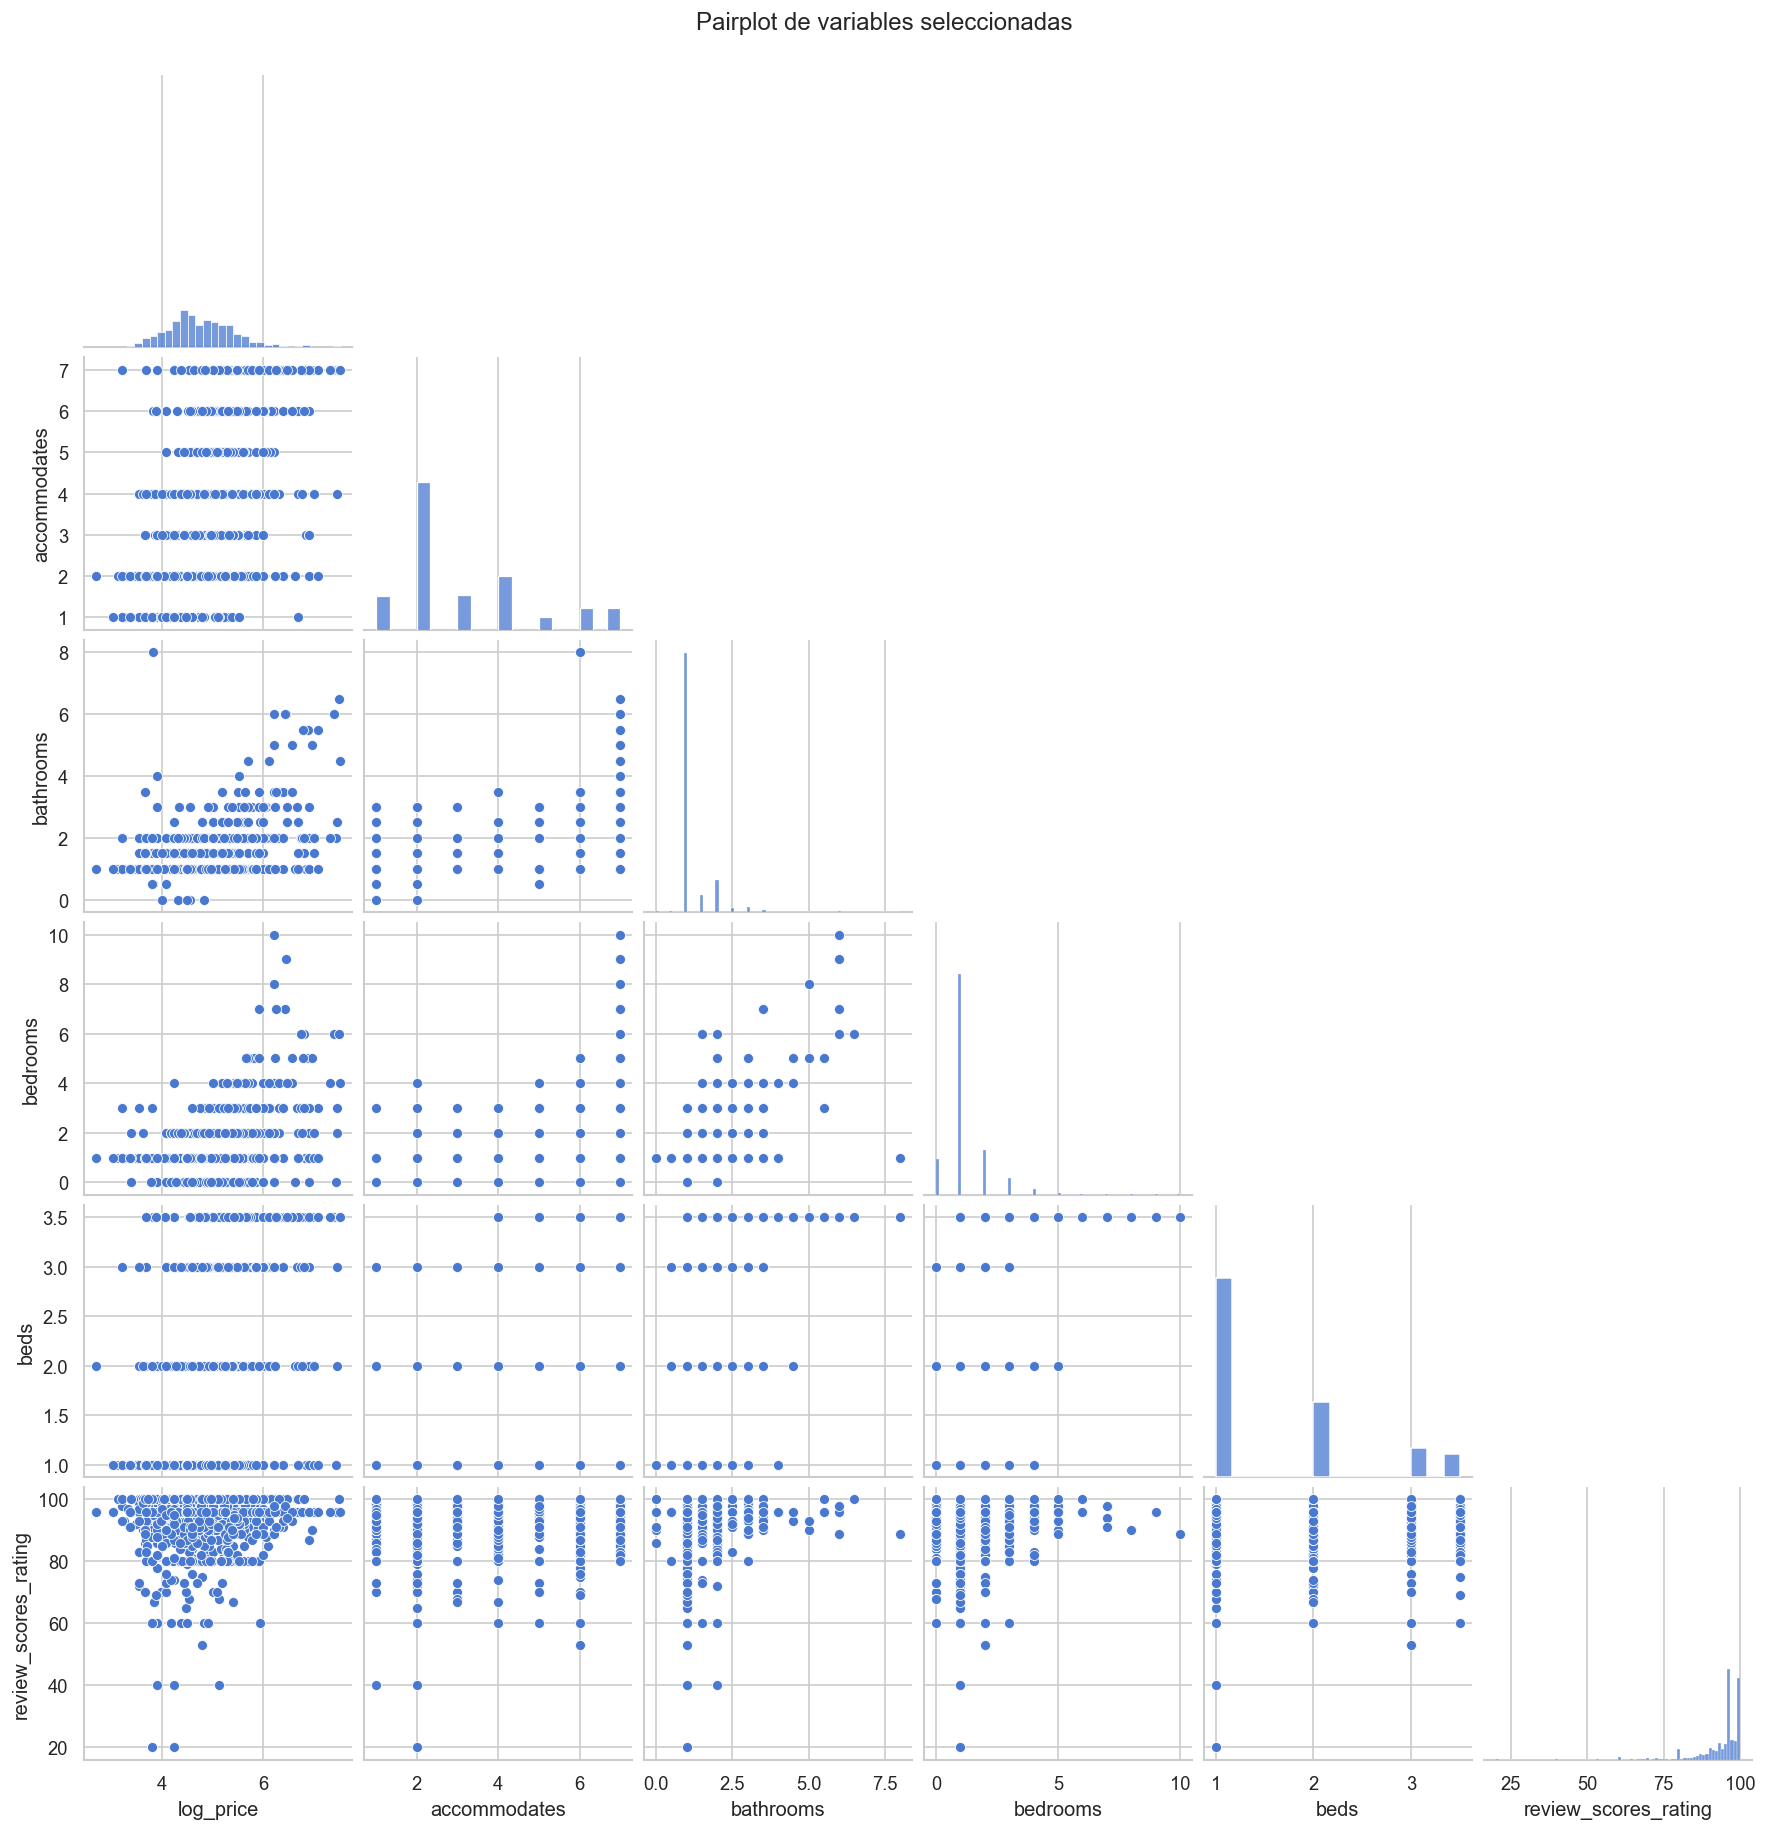

In [5]:
pairplot_columns = [TARGET_COLUMN, "accommodates", "bathrooms", "bedrooms", "beds", "review_scores_rating"]
pairplot_sample = clean_df[pairplot_columns].sample(n=min(1500, len(clean_df)), random_state=42)
pairplot = sns.pairplot(pairplot_sample, corner=True)
pairplot.fig.suptitle("Pairplot de variables seleccionadas", y=1.02)
pairplot.fig.savefig(VISUALS_DIR / "pairplot_variables.png", bbox_inches="tight")
plt.show()

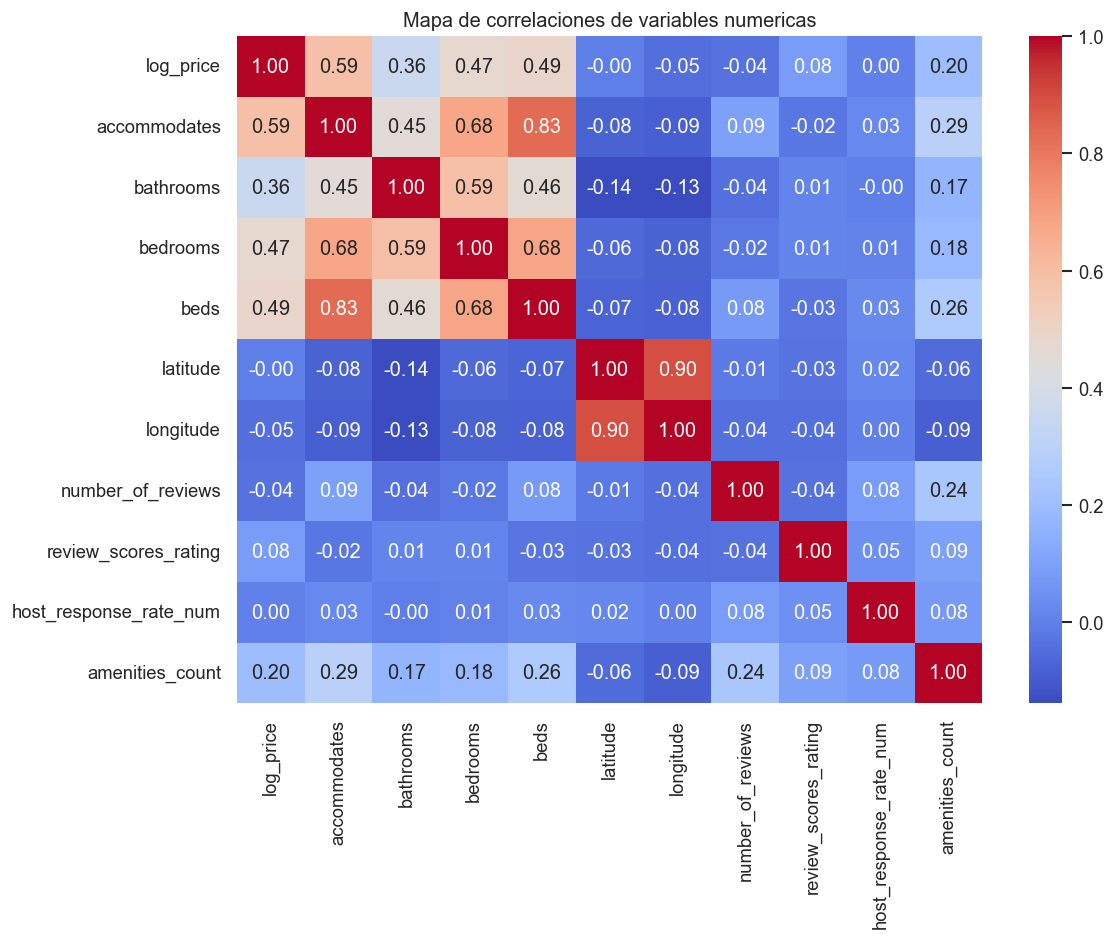

In [6]:
corr = clean_df[[TARGET_COLUMN, *NUMERIC_FEATURES]].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Mapa de correlaciones de variables numericas")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "heatmap_correlaciones.png", bbox_inches="tight")
plt.show()

## 5. Entrenamiento del modelo

In [7]:
def calculate_vif(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    numeric_df = df[columns].dropna().copy()
    numeric_df = numeric_df.loc[:, numeric_df.nunique(dropna=True) > 1]
    vif_values = [
        variance_inflation_factor(numeric_df.values, index)
        for index in range(numeric_df.shape[1])
    ]
    return pd.DataFrame({"feature": numeric_df.columns, "vif": vif_values}).sort_values("vif", ascending=False)


def adjusted_r2_score(r2_value: float, n_rows: int, n_features: int) -> float:
    if n_rows <= n_features + 1:
        return float("nan")
    return 1 - (1 - r2_value) * (n_rows - 1) / (n_rows - n_features - 1)


def build_pipeline() -> Pipeline:
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]
    )
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, NUMERIC_FEATURES),
            ("cat", categorical_transformer, CATEGORICAL_FEATURES),
        ]
    )
    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", LinearRegression()),
        ]
    )


X = clean_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = clean_df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

pipeline = build_pipeline()
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
metrics = {
    "R2": r2_score(y_test, y_pred),
    "R2 ajustado": adjusted_r2_score(r2_score(y_test, y_pred), len(y_test), len(feature_names)),
    "MSE": mean_squared_error(y_test, y_pred),
}
metrics_df = pd.DataFrame(
    [{"metrica": key, "valor": value} for key, value in metrics.items()]
)
metrics_df

,metrica,valor
0,R2,0.5787
1,R2 ajustado,0.5775
2,MSE,0.2164


In [8]:
vif_df = calculate_vif(clean_df, NUMERIC_FEATURES)
display(Markdown("### Revision de multicolinealidad (VIF)"))
vif_df

### Revision de multicolinealidad (VIF)

,feature,vif
7,review_scores_rating,170.6211
4,latitude,123.1845
8,host_response_rate_num,45.3090
5,longitude,25.3746
3,beds,16.5870
0,accommodates,15.0778
9,amenities_count,9.5241
1,bathrooms,8.6640
2,bedrooms,7.8447
6,number_of_reviews,1.7809


## 6. Visualizaciones de resultados

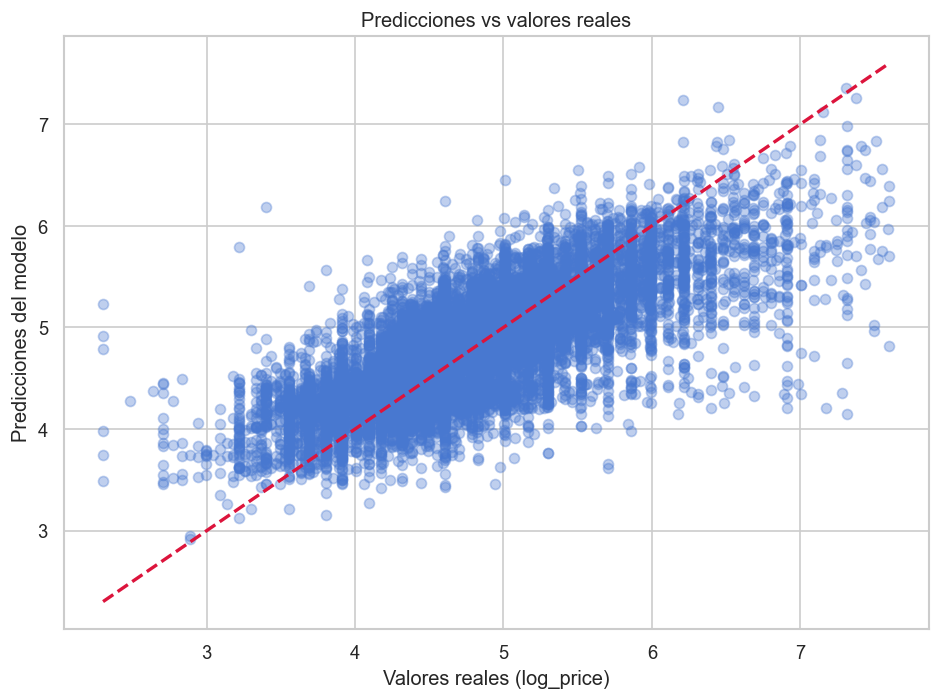

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.35)
bounds = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(bounds, bounds, color="crimson", linestyle="--", linewidth=2)
plt.title("Predicciones vs valores reales")
plt.xlabel("Valores reales (log_price)")
plt.ylabel("Predicciones del modelo")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "predicciones_vs_reales.png", bbox_inches="tight")
plt.show()

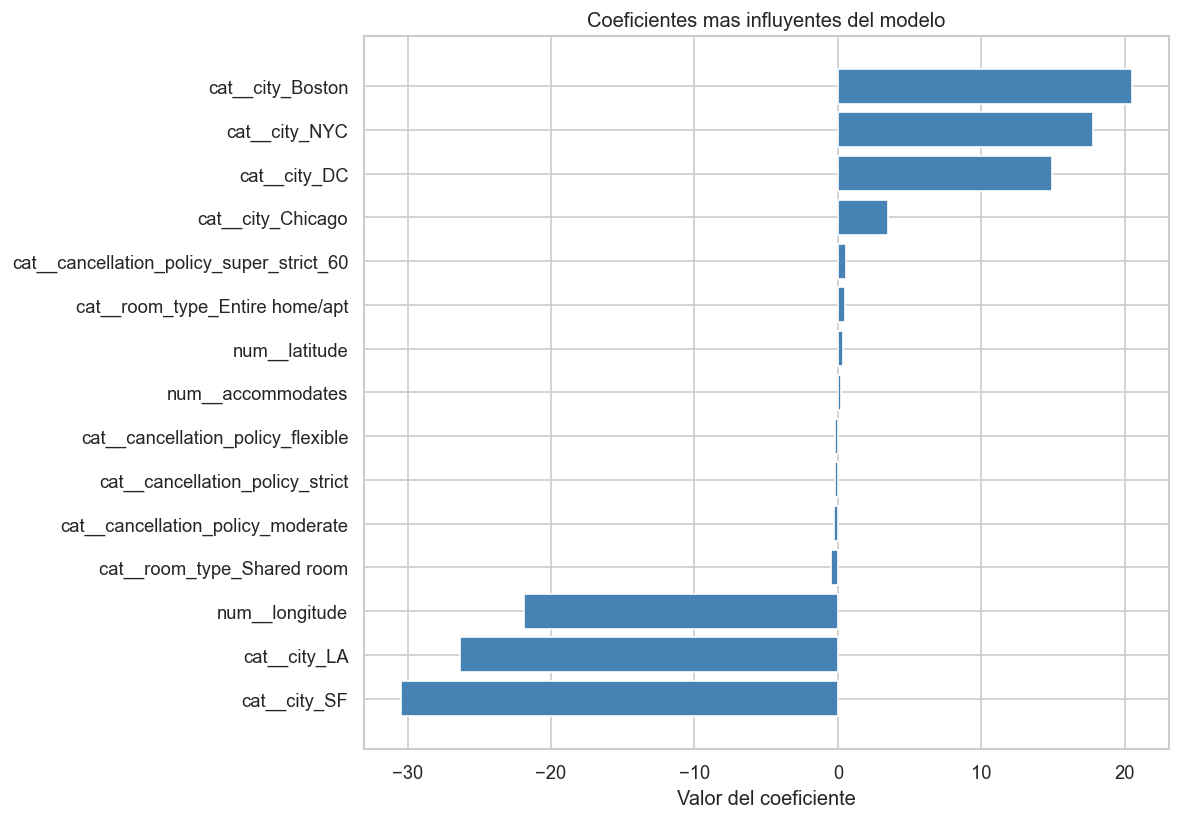

,feature,coefficient,abs_coefficient
36,cat__city_SF,-30.4694,30.4694
34,cat__city_LA,-26.3427,26.3427
5,num__longitude,-21.8974,21.8974
31,cat__city_Boston,20.5206,20.5206
35,cat__city_NYC,17.8063,17.8063
33,cat__city_DC,14.9568,14.9568
32,cat__city_Chicago,3.5284,3.5284
28,cat__cancellation_policy_super_strict_60,0.5371,0.5371
16,cat__room_type_Entire home/apt,0.5285,0.5285
18,cat__room_type_Shared room,-0.4873,0.4873


In [10]:
coeff_df = (
    pd.DataFrame(
        {
            "feature": feature_names,
            "coefficient": pipeline.named_steps["model"].coef_,
        }
    )
    .assign(abs_coefficient=lambda frame: frame["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
)

top_coefficients = coeff_df.head(15).sort_values("coefficient")
plt.figure(figsize=(10, 7))
plt.barh(top_coefficients["feature"], top_coefficients["coefficient"], color="steelblue")
plt.title("Coeficientes mas influyentes del modelo")
plt.xlabel("Valor del coeficiente")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "coeficientes_modelo.png", bbox_inches="tight")
plt.show()

coeff_df.head(10)

## 7. Reporte narrativo

In [11]:
top_positive = coeff_df.sort_values("coefficient", ascending=False).head(5)
top_negative = coeff_df.sort_values("coefficient").head(5)

report_lines = [
    "# Reporte del Proyecto Final - Semana 7",
    "",
    "## Resumen del proceso",
    "",
    f"- Filas originales: {summary.rows_original:,}",
    f"- Filas despues de limpieza: {summary.rows_clean:,}",
    f"- Duplicados eliminados: {summary.duplicates_removed}",
    "- Se imputaron valores faltantes y se acotaron outliers con el criterio IQR en variables clave.",
    "",
    "## Metricas del modelo",
    "",
    f"- R2: {metrics['R2']:.4f}",
    f"- R2 ajustado: {metrics['R2 ajustado']:.4f}",
    f"- MSE: {metrics['MSE']:.4f}",
    "",
    "## Variables con mayor efecto positivo",
    "",
]

report_lines.extend(
    [f"- {row.feature}: {row.coefficient:.4f}" for row in top_positive.itertuples(index=False)]
)
report_lines.extend([
    "",
    "## Variables con mayor efecto negativo",
    "",
])
report_lines.extend(
    [f"- {row.feature}: {row.coefficient:.4f}" for row in top_negative.itertuples(index=False)]
)
report_lines.extend([
    "",
    "## Interpretacion",
    "",
    "El modelo explica una parte relevante de la variacion del precio logaritmico del alojamiento. La senal mas fuerte proviene de variables estructurales del anuncio, ubicacion y algunas caracteristicas operativas.",
    "",
    "La grafica de predicciones vs valores reales muestra un ajuste razonable, aunque todavia existe dispersion. Esto sugiere que el modelo es util como linea base, pero puede mejorar con mas ingenieria de variables y experimentacion con modelos adicionales.",
    "",
    "## Conclusiones",
    "",
    "1. La limpieza y transformacion de datos fue necesaria para convertir el avance exploratorio en un flujo de modelado reproducible.",
    "2. La regresion lineal multiple ofrece una interpretacion clara de como ciertas caracteristicas influyen en el precio.",
    "3. Las visualizaciones facilitan comunicar tanto el desempeno del modelo como la influencia de las variables seleccionadas.",
])

report_text = "\n".join(report_lines)
display(Markdown(report_text))

# Reporte del Proyecto Final - Semana 7

## Resumen del proceso

- Filas originales: 74,111
- Filas despues de limpieza: 74,111
- Duplicados eliminados: 0
- Se imputaron valores faltantes y se acotaron outliers con el criterio IQR en variables clave.

## Metricas del modelo

- R2: 0.5787
- R2 ajustado: 0.5775
- MSE: 0.2164

## Variables con mayor efecto positivo

- cat__city_Boston: 20.5206
- cat__city_NYC: 17.8063
- cat__city_DC: 14.9568
- cat__city_Chicago: 3.5284
- cat__cancellation_policy_super_strict_60: 0.5371

## Variables con mayor efecto negativo

- cat__city_SF: -30.4694
- cat__city_LA: -26.3427
- num__longitude: -21.8974
- cat__room_type_Shared room: -0.4873
- cat__cancellation_policy_moderate: -0.2420

## Interpretacion

El modelo explica una parte relevante de la variacion del precio logaritmico del alojamiento. La senal mas fuerte proviene de variables estructurales del anuncio, ubicacion y algunas caracteristicas operativas.

La grafica de predicciones vs valores reales muestra un ajuste razonable, aunque todavia existe dispersion. Esto sugiere que el modelo es util como linea base, pero puede mejorar con mas ingenieria de variables y experimentacion con modelos adicionales.

## Conclusiones

1. La limpieza y transformacion de datos fue necesaria para convertir el avance exploratorio en un flujo de modelado reproducible.
2. La regresion lineal multiple ofrece una interpretacion clara de como ciertas caracteristicas influyen en el precio.
3. Las visualizaciones facilitan comunicar tanto el desempeno del modelo como la influencia de las variables seleccionadas.

1600